In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
data = load_breast_cancer()

In [8]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [10]:
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
scaler = StandardScaler()

In [14]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [21]:
model_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
model_none.fit(X_train, y_train)

LogisticRegression(max_iter=10000, penalty=None)

In [23]:
model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=10000)
model_l1.fit(X_train, y_train)

LogisticRegression(max_iter=10000, penalty='l1', solver='liblinear')

In [24]:
model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000)
model_l2.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [26]:
print('No reg accuracy', accuracy_score(y_test, model_none.predict(X_test)))
print('L1 reg accuracy', accuracy_score(y_test, model_l1.predict(X_test)))
print('L2 reg accuracy', accuracy_score(y_test, model_l2.predict(X_test)))

No reg accuracy 0.9385964912280702
L1 reg accuracy 0.9736842105263158
L2 reg accuracy 0.9736842105263158


In [27]:
coefficient_df = pd.DataFrame({
    'Feature': data.feature_names,
    'No Reg': model_none.coef_[0],
    'L1 Reg': model_l1.coef_[0],
    'L2 Reg': model_l2.coef_[0]
})
coefficient_df

,Feature,No Reg,L1 Reg,L2 Reg
0,mean radius,8.670792,0.000000,-0.434647
1,mean texture,-7.155953,0.000000,-0.397194
2,mean perimeter,44.028430,0.000000,-0.396070
3,mean area,10.516992,0.000000,-0.469990
4,mean smoothness,-0.052987,0.000000,-0.067394
5,mean compactness,324.100136,0.000000,0.526717
6,mean concavity,-157.740047,0.000000,-0.807676
7,mean concave points,-304.408125,-2.364905,-1.107711
8,mean symmetry,50.274460,0.040096,0.241538
9,mean fractal dimension,-189.615281,0.000000,0.078447


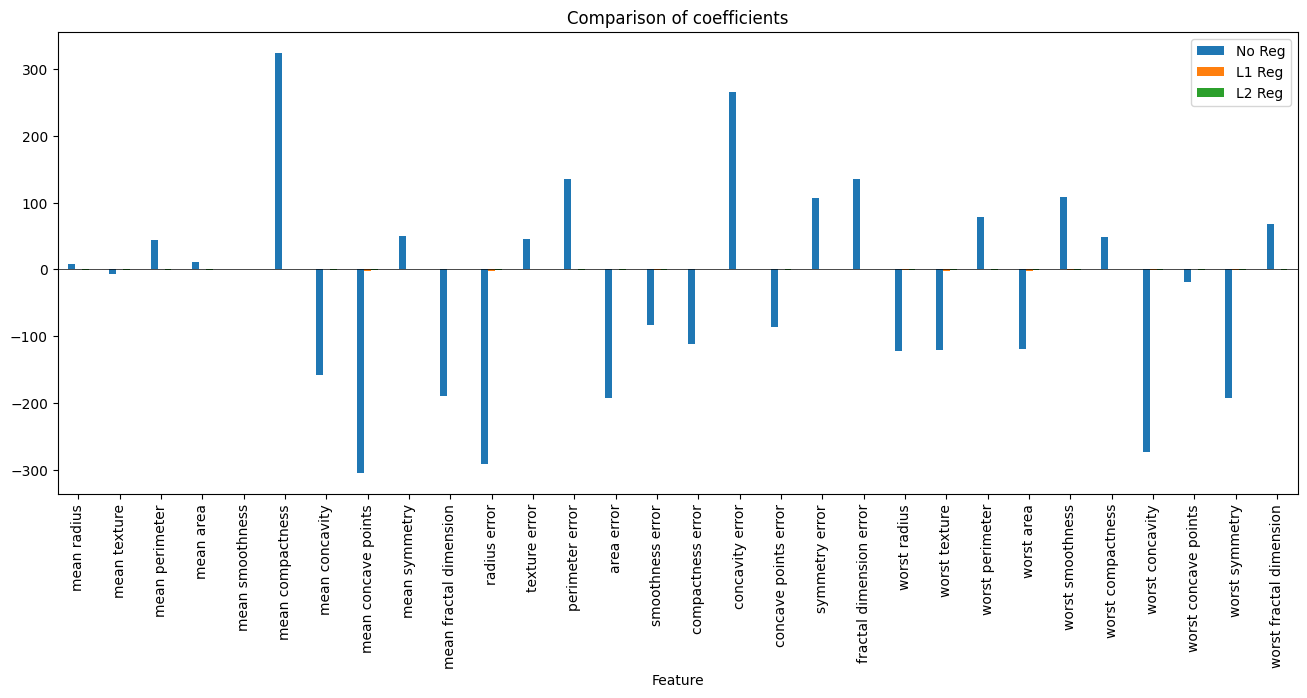

In [30]:
coefficient_df.set_index('Feature').plot(kind='bar', figsize=(16, 6))
plt.title('Comparison of coefficients')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()
